In [ ]:
import datetime as dt

import contextily as cx
import geopandas as gpd
import pandas as pd
from meteora import clients, utils

In [ ]:
spatial_extent_filepath = "../data/processed/zurich-extent.gpkg"

# study period (e.g., JJA)
# # reference data to get study period
# ref_ts_df_filepath = "../data/raw/parallel-2025-int.csv"
# year = 2025
start_year = 2023
end_year = 2024
start_month = 6
end_month = 8

# output files
dst_ts_df_filepath = "../data/interim/zurich-lcd-ts-df.csv"
dst_stations_gdf_filepath = "../data/interim/zurich-lcd-stations.gpkg"

In [ ]:
region_gser = gpd.read_file(spatial_extent_filepath)["geometry"]

In [ ]:
client = clients.AWELClient(region_gser)
stations_gdf = client.stations_gdf.assign(source="AWEL").to_crs(region_gser.crs)
stations_gdf.index = stations_gdf.index.astype(str)

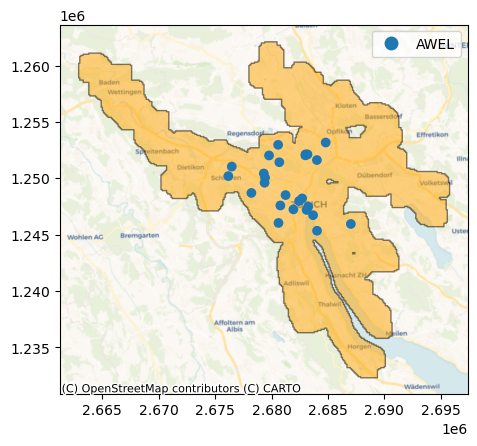

In [ ]:
ax = region_gser.plot(color="orange", edgecolor="k", alpha=0.5)
stations_gdf.plot("source", ax=ax, legend=True)
cx.add_basemap(ax, crs=region_gser.crs, source=cx.providers.CartoDB.Voyager)

In [ ]:
# # read reference data to get study period
# ref_ts_df = pd.read_csv(ref_ts_df_filepath, parse_dates=["time"]).set_index("time")

# # get data for study period
# ts_df = (
#     utils.long_to_wide(
#         client.get_ts_df("temperature", ref_ts_df.index[0], ref_ts_df.index[-1])
#     )
#     .resample("h")
#     .mean()
# )
# note that we need to transform each year data to wide and resample it before concat
# otherwise resample would add nan rows for all the missing non-JJA data
ts_df = pd.concat(
    [
        utils.long_to_wide(
            client.get_ts_df(
                "temperature",
                # pd.Timestamp(start),
                # dt.datetime.combine(
                #     pd.Timestamp(end),
                #     dt.time.max,
                # ),
                dt.date(year, start_month, 1),
                # get latest moment of the latest day of the month
                # ACHTUNG: this won't work if `end_month` is 12 (see commented code
                # below)
                dt.datetime.combine(
                    dt.date(year, end_month + 1, 1) - dt.timedelta(days=1),
                    dt.time.max,
                ),
            )
        )
        .resample("h")
        .mean()
        for year in range(start_year, end_year + 1)
    ]
)
ts_df.columns = ts_df.columns.astype(str)
ts_df.head()

station_id,530,534,2650,2651,2652,2653,2655,2657,2658,2659,...,2680,2681,2682,2683,2688,2689,2695,2696,2697,2810
time,,,,,,,,,,,,,,,,,,,,,
2023-06-01 00:00:00,14.685000,17.660000,15.675000,15.448333,17.798333,14.598333,16.813333,15.591667,13.735000,17.446000,...,18.481667,14.656667,18.128333,15.776667,16.733333,17.466667,16.853333,15.601667,14.308333,14.691667
2023-06-01 01:00:00,14.081667,17.011667,15.020000,14.846000,17.081667,13.785000,16.116667,14.596667,12.841667,16.812000,...,17.721667,13.816667,17.296667,15.020000,16.263333,16.810000,15.930000,14.801667,13.681667,13.876667
2023-06-01 02:00:00,13.521667,16.430000,14.470000,14.052000,16.264000,12.926667,15.573333,13.956000,12.338333,16.296000,...,17.260000,13.212000,16.550000,14.240000,15.831667,16.148333,15.331667,14.168333,13.013333,13.256667
2023-06-01 03:00:00,12.980000,15.800000,13.928333,13.106667,15.755000,11.730000,15.101667,13.515000,11.733333,15.598333,...,17.076000,12.865000,15.631667,13.838333,15.283333,15.833333,15.271667,13.548333,12.628000,12.542000
2023-06-01 04:00:00,13.020000,15.840000,14.245000,13.205000,15.981667,12.200000,14.790000,13.318333,12.511667,16.017500,...,16.856667,13.220000,15.820000,14.026667,15.171667,15.720000,15.110000,13.468333,12.710000,12.678333


In [ ]:
# save the time series of measurements to a file
ts_df.to_csv(dst_ts_df_filepath)
# save the stations' locations to a file
stations_gdf.to_file(dst_stations_gdf_filepath)